# S2.3 融合阶段：基于帕累托法则 (ABC分类) 的高优先级风险场景识别
本阶段目标 本笔记本旨在将 S2.1 和 S2.2 的结果进行定量融合。我们将摒弃简单的“交集筛选”，转而采用帕累托分析法 (Pareto Analysis / ABC Classification)：
量化：构建一个综合风险指数 (CRI)，同时考量风险组合的“发生频率/提升度”（来自 S2.1）和“致因重要性”（来自 S2.2）。
排序：依据 CRI 对所有风险场景进行排序。
分类：应用二八定律，识别出累积贡献度达到 80% 的 A类风险场景（高优先级），作为最终的整改建议依据。

## 步骤一.导入库与数据加载

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # 用于解析字符串格式的字典 "{'key': 'val'}"
import re
import os

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 当前分析的州名 (用于自动加载对应数据文件)
# 可选值: "California", "Texas", "Illinois"
STATE_NAME = "Illinois"  

# 2. 上游模型版本 (用于区分实验批次或参数，将用于文件夹命名)
MODEL_VERSION = "xgb_baseline_v1"
EXPERIMENT_NAME = "transformer_fusion_experiment_v1" 

# 3. 融合权重配置 
W1_CONFIG = 0.1  # S2.1 规则(Uplift)的权重
W2_CONFIG = 0.9  # S2.2 模型(Importance)的权重

DATA_DIR = os.path.join('..', 'data', 'processed')
# RESULTS_ROOT = os.path.join('..', 'results', 'reports')
RESULTS_ROOT = os.path.join('..', 'results', EXPERIMENT_NAME, STATE_NAME)
os.makedirs(RESULTS_ROOT, exist_ok=True)

# --- 1. 定义动态文件路径 ---
S2_1_FULL_DIR = os.path.join(DATA_DIR, 's2_1_full_results')
# S2.1 全量数据文件名 (标准命名格式: {state}_s2_1_full.csv)
s2_1_filename = f'{STATE_NAME.lower()}_s2_1_full.csv'

# S2.2 特征重要性文件名
# 根据 STATE_NAME 自动选择对应的输入文件
# 注意：加州的文件名与后续处理的州文件名格式可能不同，这里做了兼容处理
if STATE_NAME.lower() == 'california':
    # 加州使用原有文件名
    # s2_1_filename = 'high_risk_combinations_analysis_from_preprocessed.csv'
    s2_2_filename = 'california_high_contribution_features2.csv'
else:
    # 其他州使用标准命名格式: {state}_top100... 和 {state}_high_contribution...
    # s2_1_filename = f'{STATE_NAME.lower()}_top100_per_accident_type.csv'
    s2_2_filename = f'{STATE_NAME.lower()}_high_contribution_features.csv'

S2_1_FILE = os.path.join(S2_1_FULL_DIR, s2_1_filename)
S2_2_FILE = os.path.join(DATA_DIR, s2_2_filename)

print(f"当前分析对象: {STATE_NAME}")
print(f"正在加载 S2.1 全量文件: {s2_1_filename} (路径: {S2_1_FULL_DIR})")
print(f"正在加载 S2.2 文件: {s2_2_filename}")

# --- 2. 加载数据 ---
try:
    # 1. 加载原始全量文件
    df_s2_1_raw = pd.read_csv(S2_1_FILE)
    df_s2_2 = pd.read_csv(S2_2_FILE)
    
    if 'Unnamed: 0' in df_s2_2.columns:
        df_s2_2.rename(columns={'Unnamed: 0': 'feature_name'}, inplace=True)

    print("\n[原始数据加载成功]")
    print(f"S2.1 原始记录数 (全量): {len(df_s2_1_raw)}")
    print(f"S2.2 特征重要性记录数: {len(df_s2_2)}")
    
    # 【修改点2】移除 Top N 筛选逻辑，直接使用全量有效数据
    # 依然保留 Uplift > 0 的基本过滤，确保规则有效
    df_s2_1 = df_s2_1_raw[df_s2_1_raw['uplift'] > 0].copy().reset_index(drop=True)
    
    print(f"\n[数据准备完成]")
    print(f"S2.1 最终用于训练的记录数: {len(df_s2_1)}")
    
except FileNotFoundError as e:
    print(f"\n错误：找不到文件，请检查路径或文件名命名规则。\n{e}")
    print(f"提示：请确认已在 {S2_1_FULL_DIR} 目录下放入了 {s2_1_filename}")

当前分析对象: Illinois
正在加载 S2.1 全量文件: illinois_s2_1_full.csv (路径: ..\data\processed\s2_1_full_results)
正在加载 S2.2 文件: illinois_high_contribution_features.csv

[原始数据加载成功]
S2.1 原始记录数 (全量): 135642
S2.2 特征重要性记录数: 156

[数据准备完成]
S2.1 最终用于训练的记录数: 56810


## 步骤二.特征映射与分数匹配
S2.1 的特征名是人类可读的（如 {'Equipment Type': 'Freight Train'}），而 S2.2 是机器生成的（如 cat__equipmenttype_Freight Train）。我们需要构建一个映射逻辑，将 S2.1 中的每一个条件“翻译”成 S2.2 的格式，以便查询其重要性分数。
- 如果一个组合包含多个特征（如 A 和 B），我们取它们重要性的平均值（或最大值）作为该组合的“S2.2 得分”。
- 如果某个特征在 S2.2 中找不到，则默认其重要性为 0。
如果 S2.2 原始 CSV 文件里有一行是：
Feature: cat__Equipment Type_Freight Train
Importance: 0.052
那么存进 s2_2_dict 之后就是：
Key: "equipmenttype_freighttrain"
Value: 0.052

In [9]:
# --- 1. 构建 S2.2 特征查询字典 ---
# 这里的 Key 是处理过的简化版特征名，Value 是重要性分数
# 目的是为了模糊匹配（忽略大小写和部分特殊字符的差异）
s2_2_dict = {}

for index, row in df_s2_2.iterrows():
    raw_name = str(row['feature_name'])
    score = row['importance_score']
    
    # 简化处理：转小写，去除 'cat__', 'num__' 前缀，去除空格
    # 例如: 'cat__Equipment Type_Freight Train' -> 'equipmenttype_freighttrain'
    simple_name = raw_name.lower().replace('cat__', '').replace('num__', '').replace(' ', '').replace('/', '').replace('.', '')
    s2_2_dict[simple_name] = score

print(f"构建了包含 {len(s2_2_dict)} 个特征的重要性查询字典。")

# --- 2. 定义映射函数 ---
def get_combination_importance(evidence_str):
    """
    解析 evidence 字符串，查找其中每个特征在 S2.2 中的重要性，
    并返回该组合的【平均重要性分数】。
    """
    try:
        # 将字符串 "{'Key': 'Val'}" 转为字典
        evidence_dict = ast.literal_eval(evidence_str)
    except:
        return 0.0
    
    scores = []
    matched_features = []
    
    for col, val in evidence_dict.items():
        # 构造尝试匹配的字符串
        # S2.2 的格式通常是: 列名_值 (对于分类) 或 列名 (对于数值)
        # 我们尝试构建几种可能的组合进行匹配
        
        # 尝试 1: 拼接 Key + Value (针对分类变量)
        query_str_1 = f"{col}_{val}".lower().replace(' ', '').replace('/', '').replace('.', '')
        
        # 尝试 2: 仅 Key (针对数值变量，S2.2里通常是 num__colname)
        query_str_2 = f"{col}".lower().replace(' ', '').replace('/', '').replace('.', '')

        score = 0.0
        if query_str_1 in s2_2_dict:
            score = s2_2_dict[query_str_1]
            matched_features.append(f"{col}={val}(Score:{score:.4f})")
        elif query_str_2 in s2_2_dict:
            score = s2_2_dict[query_str_2]
            matched_features.append(f"{col}(Score:{score:.4f})")
        else:
            # 没找到匹配，分数为 0
            matched_features.append(f"{col}={val}(N/A)")
            
        scores.append(score)
    
    # 计算平均重要性 (如果组合里有多个条件，取平均值代表该组合的整体致因强度)
    avg_importance = np.mean(scores) if scores else 0.0
    return avg_importance, "; ".join(matched_features)

# --- 3. 应用映射 ---
# 在 S2.1 DataFrame 中添加 's2_2_importance' 列
results = df_s2_1.apply(lambda row: get_combination_importance(row['evidence']), axis=1, result_type='expand')
df_s2_1['s2_2_importance'] = results[0]
df_s2_1['matched_details'] = results[1]

print("特征匹配完成。前 5 行预览：")
display(df_s2_1[['accident_type', 'evidence', 'uplift', 's2_2_importance']].head())

构建了包含 155 个特征的重要性查询字典。
特征匹配完成。前 5 行预览：


,accident_type,evidence,uplift,s2_2_importance
0,Broken train collision,{'Equipment Type': 'Cut of cars'},0.004632,0.006246
1,Broken train collision,"{'Visibility': 'Dark', 'Equipment Type': 'Cut ...",0.004632,0.003269
2,Broken train collision,"{'Equipment Type': 'Cut of cars', 'Visibility'...",0.004632,0.003261
3,Broken train collision,"{'Equipment Type': 'Cut of cars', 'Weather Con...",0.004632,0.003165
4,Broken train collision,"{'Equipment Type': 'Cut of cars', 'Weather Con...",0.004632,0.003488


## 步骤三.构建综合风险指数 (CRI)
归一化与加权为了进行公平比较，需要消除量纲影响。
- Uplift (S2.1)：范围通常在 0.0 ~ 0.5 之间。
- Importance (S2.2)：范围通常在 0.0 ~ 0.05 之间。
我们将使用 Min-Max 归一化 将它们都映射到 [0, 1] 区间。综合得分公式：
$$\text{CRI} = w_1 \times \text{Norm}(\text{Uplift}) + w_2 \times \text{Norm}(\text{Importance})$$
- 权重设定：建议设定 $w_1=0.5, w_2=0.5$（S2.1与S2.2同等重要）。如果更信任 XGBoost 的判断，可以提高 $w_2$。

In [60]:
# --- 1. 归一化函数 ---
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

# --- 2. 执行归一化 ---
df_s2_1['norm_uplift'] = min_max_norm(df_s2_1['uplift'])
df_s2_1['norm_importance'] = min_max_norm(df_s2_1['s2_2_importance'])

# --- 3. 计算综合风险指数 (CRI) ---
# 权重设定 (可调整)
W1 = W1_CONFIG  # 频率/提升度 (S2.1) 的权重
W2 = W2_CONFIG  # 致因重要性 (S2.2) 的权重

print(f"当前使用的权重配置: W1(Rule)={W1}, W2(Model)={W2}")

df_s2_1['CRI_Score'] = W1 * df_s2_1['norm_uplift'] + W2 * df_s2_1['norm_importance']

# --- 4. 排序 ---
# 按 CRI 从高到低排序
df_pareto = df_s2_1.sort_values(by='CRI_Score', ascending=False).reset_index(drop=True)

print("综合评分计算完成。")

当前使用的权重配置: W1(Rule)=0.1, W2(Model)=0.9
综合评分计算完成。


## 步骤3.2 定义 Transformer 模型与必要的数据类

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import ast

# ==========================================
# 1. 核心模型定义 (RiskFusionTransformer)
# ==========================================
class RiskFusionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        model_dim: int = 128,
        num_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.1,
        max_sequence_length: int = 12,
        numeric_feat_dim: int = 4, # prob, lift, support, importance
        output_dim: int = 1,
    ) -> None:
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, model_dim)
        self.pos_emb = nn.Embedding(max_sequence_length, model_dim)

        self.numeric_proj = nn.Sequential(
            nn.LayerNorm(numeric_feat_dim),
            nn.Linear(numeric_feat_dim, model_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim // 2, output_dim),
        )

    def forward(self, token_ids, token_numeric, attention_mask):
        B, L = token_ids.shape
        device = token_ids.device
        pos = torch.arange(L, device=device).unsqueeze(0).expand(B, L)

        # Embedding Fusion
        x = self.token_emb(token_ids) + self.pos_emb(pos) + self.numeric_proj(token_numeric)

        src_key_padding_mask = ~attention_mask
        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)

        # Masked Mean Pooling
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        out = self.head(pooled).squeeze(-1)
        return out

# ==========================================
# 2. 数据集定义 (Dataset)
# ==========================================
class RiskScenarioDataset(Dataset):
    def __init__(self, token_ids, token_numeric, attention_mask, labels=None):
        self.token_ids = token_ids
        self.token_numeric = token_numeric
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.token_ids)

    def __getitem__(self, idx):
        item = {
            "token_ids": self.token_ids[idx],
            "token_numeric": self.token_numeric[idx],
            "attention_mask": self.attention_mask[idx],
        }
        if self.labels is not None:
            item["label"] = self.labels[idx]
        return item

# ==========================================
# 3. 数据适配工具函数 (Data Adapter)
# ==========================================
def _safe_parse_evidence(ev):
    """确保 evidence 是字典格式"""
    if isinstance(ev, dict): return ev
    try:
        return ast.literal_eval(str(ev))
    except:
        return {}

def prepare_transformer_data(df_input, feature_importance_map, max_len=12): # 建议默认设为 12
    """
    将步骤二处理好的 DataFrame 转换为 Transformer 需要的 Tensor 格式
    df_input: 步骤二生成的 DataFrame，必须包含 'evidence', 'accident_type', 'uplift' (或 lift) 等列
    feature_importance_map: 特征名到分数的映射字典 (key 需预处理为小写去特殊字符的格式，即 s2_2_dict)
    """
    # 1. 初始化统计计数器
    stats = {
        "total_features": 0,
        "matched_features": 0,
        "debug_logs": [] # 存储前几行的详细匹配日志
    }

    # 1. 构建 Token 序列和数值特征
    token_seqs = []
    token_imps = []
    
    # 获取必要的列名，兼容代码中可能的命名
    cols = df_input.columns
    prob_col = 'prob' if 'prob' in cols else ('confidence' if 'confidence' in cols else 'P')
    lift_col = 'lift' if 'lift' in cols else 'uplift' # 兼容 uplift
    support_col = 'support' if 'support' in cols else 'support_prob'
    
    # 填充缺失值
    df_use = df_input.copy()
    for c in [prob_col, lift_col, support_col]:
        if c not in df_use.columns: df_use[c] = 0.0
    
        # --- 核心循环 ---
    for idx, row in df_use.iterrows():
        ev = _safe_parse_evidence(row.get('evidence', {}))
        acc_type = str(row.get('accident_type', 'Unknown'))
        
        tokens = [f"Type={acc_type}"]
        row_imps = [0.0] 
        
        # 记录当前行的匹配详情 (仅针对前 3 行)
        row_log = []
        
        for k, v in sorted(ev.items()):
            stats["total_features"] += 1
            
            # 构造匹配 Key
            query_1 = f"{k}_{v}".lower().replace(' ', '').replace('/', '').replace('.', '')
            query_2 = f"{k}".lower().replace(' ', '').replace('/', '').replace('.', '')
            
            imp = 0.0
            match_key = "Miss"
            
            if query_1 in feature_importance_map:
                imp = feature_importance_map[query_1]
                match_key = query_1
                stats["matched_features"] += 1
            elif query_2 in feature_importance_map:
                imp = feature_importance_map[query_2]
                match_key = query_2
                stats["matched_features"] += 1
            
            tokens.append(f"{k}={v}")
            row_imps.append(imp)

            # 记录日志: 特征名 -> 匹配到的Key (分数)
            if idx < 3:
                row_log.append(f"'{k}={v}' -> {match_key}({imp:.4f})")
            
        token_seqs.append(tokens)
        token_imps.append(row_imps)

        if idx < 3 and row_log:
            stats["debug_logs"].append(f"Row {idx}: " + " | ".join(row_log))
    # --- 打印匹配报告 ---
    match_rate = stats["matched_features"] / stats["total_features"] if stats["total_features"] > 0 else 0
    print("\n" + "="*40)
    print(f" [特征重要性匹配报告] Feature Matching Report")
    print(f" Total Features Processed: {stats['total_features']}")
    print(f" Successfully Matched:   {stats['matched_features']}")
    print(f" Match Rate:             {match_rate:.2%}")
    
    if match_rate < 0.1:
        print("\n [WARNING] ⚠️ 匹配率极低 (<10%)！请检查 s2_2_dict 的 Key 是否与 Evidence 格式一致。")
        print(" 可能是 S2.2 文件加载错误，或者清洗逻辑不匹配。")
    else:
        print("\n [INFO] ✅ 匹配情况良好。")
        
    print("\n [Sample Logs] 前 3 行数据的匹配详情：")
    for log in stats["debug_logs"]:
        print(log)
    print("="*40 + "\n")

    # 2. 构建词表 (Vocab)
    # [关键修改] 确保 ID 连续且包含 PAD/UNK
    vocab = {"<PAD>": 0, "<UNK>": 1}
    next_id = 2
    for seq in token_seqs:
        for t in seq:
            if t not in vocab: 
                vocab[t] = next_id
                next_id += 1
            
    # 3. 转换为 Tensor
    N = len(df_use)
    token_ids = torch.zeros((N, max_len), dtype=torch.long)
    # 4 dim: [prob, lift, support, importance]
    token_numeric = torch.zeros((N, max_len, 4), dtype=torch.float32) 
    attention_mask = torch.zeros((N, max_len), dtype=torch.bool)
    
    for i in range(N):
        current_row = df_use.iloc[i]

        seq = token_seqs[i][:max_len]
        imps = token_imps[i][:max_len]
        
        # 提取全局数值特征
        g_prob = float(current_row[prob_col]) if prob_col in df_use.columns else 0.0
        g_lift = float(current_row[lift_col]) if lift_col in df_use.columns else 0.0
        g_supp = float(current_row[support_col]) if support_col in df_use.columns else 0.0
        
        for j, token in enumerate(seq):
            tid = vocab.get(token, vocab["<UNK>"])
            token_ids[i, j] = tid
            attention_mask[i, j] = True
            
            # 数值特征向量
            token_numeric[i, j, 0] = g_prob
            token_numeric[i, j, 1] = g_lift
            token_numeric[i, j, 2] = g_supp
            token_numeric[i, j, 3] = float(imps[j]) # 当前 token 的特征重要性
            
    # 4. 标签 (使用 Lift 作为弱监督信号)
    labels = torch.tensor(df_use[lift_col].fillna(0).values, dtype=torch.float32)
    
    return {
        "dataset": RiskScenarioDataset(token_ids, token_numeric, attention_mask, labels),
        "vocab": vocab,
        "raw_df": df_use
    }

## 步骤3.3 执行训练并计算新的 Transformer-CRI

In [ ]:
# ==========================================
# 4. 执行 Transformer 融合与 CRI 计算 (Step 3.3) - 优化版
# ==========================================
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import numpy as np

# -----------------------------------------------------
# 1. 准备数据
# -----------------------------------------------------
target_df = df_s2_1.copy()

print("正在构建 Transformer 输入数据...")

# 构建全量数据集
data_bundle = prepare_transformer_data(
    df_input=target_df, 
    feature_importance_map=s2_2_dict, 
    max_len=12
)

full_dataset = data_bundle["dataset"]
vocab_size = len(data_bundle["vocab"])

# --- 数值特征归一化 ---
# 目的：将 Lift(约5.0) 和 Importance(约0.001) 拉到同一量级，避免模型忽略 Importance
# ----------------------------------------------------------
print("正在执行数值特征归一化 (Feature Scaling)...")
# 获取所有数据的数值特征张量 (N, L, 4)
all_numeric = full_dataset.token_numeric

# 计算全局均值和标准差 (dim=0,1 表示跨样本和跨序列长度计算)
# 也就是算出整个数据集里：平均 Lift 是多少，平均 Importance 是多少
# 注意：即使包括了 padding 的 0也没关系，大数定律下差异不大，主要是拉开量级
flat_numeric = all_numeric.view(-1, 4) # 展平为 (Total_Tokens, 4)
mean = flat_numeric.mean(dim=0)
std = flat_numeric.std(dim=0) + 1e-6   # 加个极小值防止除以0

# 执行原地归一化
full_dataset.token_numeric = (all_numeric - mean) / std

print(f"  - 归一化前 Importance 均值: {mean[3].item():.6f}")
print(f"  - 归一化后 Importance 均值: {full_dataset.token_numeric[:,:,3].mean().item():.6f}")
# ----------------------------------------------------------

# 划分训练集和验证集 (80% Train, 20% Val)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

print(f"数据划分完成: 训练集 {len(train_dataset)} 条, 验证集 {len(val_dataset)} 条")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -----------------------------------------------------
# 2. 初始化模型与优化器
# -----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

MAX_SEQ_LEN = 12 

model = RiskFusionTransformer(
    vocab_size=vocab_size, 
    num_layers=2,        # 保持 2 层
    dropout=0.3,         # 【微调】从 0.2 增加到 0.3，加强正则化，强迫模型利用所有特征
    max_sequence_length=MAX_SEQ_LEN
).to(device)

# 增加 weight_decay 防止过拟合
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3) 
loss_fn = nn.MSELoss()

# -----------------------------------------------------
# 3. 训练循环
# -----------------------------------------------------
print("开始训练 Transformer (Weak Supervision on Lift)...")

epochs = 50
patience = 8          # 【微调】增加一点耐心，让模型多学一会儿
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    # --- 训练阶段 ---
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        ids = batch['token_ids'].to(device)
        nums = batch['token_numeric'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        preds = model(ids, nums, mask)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * len(ids)
    
    avg_train_loss = total_train_loss / len(train_dataset)
    
    # --- 验证阶段 ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['token_ids'].to(device)
            nums = batch['token_numeric'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            preds = model(ids, nums, mask)
            loss = loss_fn(preds, labels)
            total_val_loss += loss.item() * len(ids)
            
    avg_val_loss = total_val_loss / len(val_dataset)
    
    # 打印进度
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # 早停检查
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停触发! 验证集 Loss 在 {patience} 个 Epoch 内未下降 (Epoch {epoch+1})")
            break

# 恢复最佳权重
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"已加载最佳模型权重 (Best Val Loss: {best_val_loss:.4f})")

# -----------------------------------------------------
# 4. 全量预测 & 结果更新
# -----------------------------------------------------
print("正在计算 Transformer-CRI (全量预测)...")
model.eval()

full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False)
all_preds = []

with torch.no_grad():
    for batch in full_loader:
        ids = batch['token_ids'].to(device)
        nums = batch['token_numeric'].to(device)
        mask = batch['attention_mask'].to(device)
        preds = model(ids, nums, mask)
        all_preds.extend(preds.cpu().numpy())

# 保存结果
target_df['CRI_Transformer'] = all_preds
df_s2_1 = target_df  # 更新全局变量

print("\n=== CRI 结果对比 (Top 5) ===")
cols_to_show = ['accident_type', 'evidence', 'lift' if 'lift' in target_df.columns else 'uplift', 'CRI_Transformer']
display(target_df.sort_values('CRI_Transformer', ascending=False)[cols_to_show].head(5))

正在构建 Transformer 输入数据...

 [特征重要性匹配报告] Feature Matching Report
 Total Features Processed: 112529
 Successfully Matched:   76808
 Match Rate:             68.26%

 [INFO] ✅ 匹配情况良好。

 [Sample Logs] 前 3 行数据的匹配详情：
Row 0: 'Equipment Type=Cut of cars' -> equipmenttype_cutofcars(0.0062)
Row 1: 'Equipment Type=Cut of cars' -> equipmenttype_cutofcars(0.0062) | 'Visibility=Dark' -> visibility_dark(0.0003)
Row 2: 'Equipment Type=Cut of cars' -> equipmenttype_cutofcars(0.0062) | 'Visibility=Day' -> visibility_day(0.0003)

正在执行数值特征归一化 (Feature Scaling)...
  - 归一化前 Importance 均值: 0.000326
  - 归一化后 Importance 均值: -0.000000
数据划分完成: 训练集 45448 条, 验证集 11362 条
使用设备: cpu
开始训练 Transformer (Weak Supervision on Lift)...


d:\MyProjects\ResearchProjects\railway_risk_analysis\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 1/50 | Train Loss: 0.1527 | Val Loss: 0.0639
Epoch 5/50 | Train Loss: 0.0461 | Val Loss: 0.0155
Epoch 10/50 | Train Loss: 0.0395 | Val Loss: 0.0174
Epoch 15/50 | Train Loss: 0.0295 | Val Loss: 0.0235
Epoch 20/50 | Train Loss: 0.0268 | Val Loss: 0.0112
Epoch 25/50 | Train Loss: 0.0241 | Val Loss: 0.0121
Epoch 30/50 | Train Loss: 0.0245 | Val Loss: 0.0092
Epoch 35/50 | Train Loss: 0.0265 | Val Loss: 0.0126
Epoch 40/50 | Train Loss: 0.0214 | Val Loss: 0.0080
Epoch 45/50 | Train Loss: 0.0240 | Val Loss: 0.0060
Epoch 50/50 | Train Loss: 0.0196 | Val Loss: 0.0116
已加载最佳模型权重 (Best Val Loss: 0.0052)
正在计算 Transformer-CRI (全量预测)...

=== CRI 结果对比 (Top 5) ===


,accident_type,evidence,lift,CRI_Transformer
22942,Hwy-rail crossing,{'Equipment Type': 'Passenger Train - Pulling'},11.120393,9.164427
22948,Hwy-rail crossing,{'Equipment Type': 'Passenger Train - Pulling'...,11.120393,8.957216
22973,Hwy-rail crossing,{'Passengers Transported': 'Yes'},10.448593,8.949078
22955,Hwy-rail crossing,"{'Empty Freight Cars': '0', 'Equipment Type': ...",11.120393,8.942100
22949,Hwy-rail crossing,"{'Remote Control Locomotive': 'UNKNOWN', 'Equi...",11.120393,8.939933


## 步骤四.帕累托分析 (ABC分类)
根据论文方法论，计算 **累积贡献度** (Cumulative Contribution)。
- A 类 (0% - 80%)：核心风险场景。这是我们需要重点汇报和整改的“关键少数”。
- B 类 (80% - 90%)：次要风险场景。
- C 类 (90% - 100%)：一般风险场景。

--- ABC Classification Results (Based on Transformer CRI) ---
Class
A    43703
B     6510
C     6597
Name: count, dtype: int64

识别出 A 类风险场景: 43703 条
占总场景数的: 76.93%


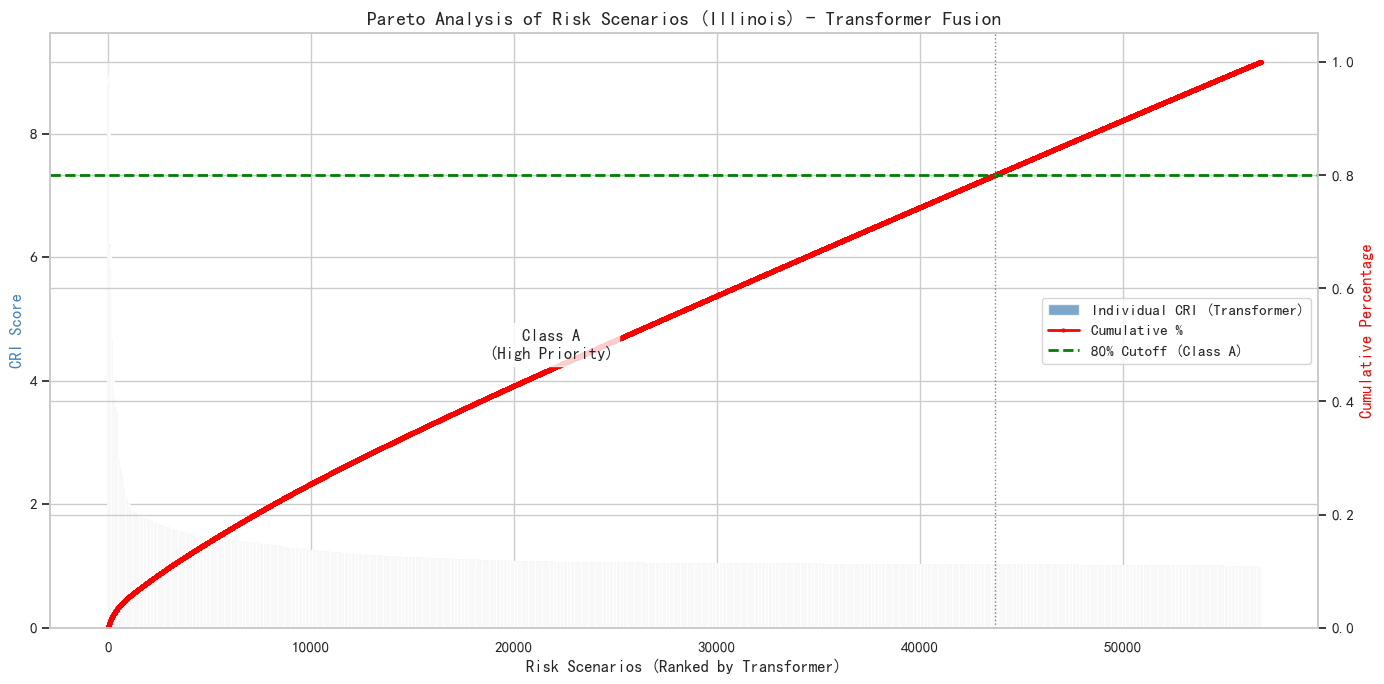


A 类风险清单已保存至: ..\results\transformer_fusion_experiment_v1\Illinois\illinois_transformer_class_a_risks.csv

Top 5 Class A Risks:


,accident_type,evidence,lift,s2_2_importance,CRI_Transformer,Class
0,Hwy-rail crossing,{'Equipment Type': 'Passenger Train - Pulling'},11.120393,0.000424,9.164427,A
1,Hwy-rail crossing,{'Equipment Type': 'Passenger Train - Pulling'...,11.120393,0.000212,8.957216,A
2,Hwy-rail crossing,{'Passengers Transported': 'Yes'},10.448593,0.000000,8.949078,A
3,Hwy-rail crossing,"{'Empty Freight Cars': '0', 'Equipment Type': ...",11.120393,0.000844,8.942100,A
4,Hwy-rail crossing,"{'Remote Control Locomotive': 'UNKNOWN', 'Equi...",11.120393,0.000212,8.939933,A


In [12]:
# ==========================================
# 5. 帕累托法则分析 (Pareto Analysis) - 基于 Transformer CRI
# ==========================================

# 1. 排序：按 Transformer 计算出的 CRI 分数从高到低排序
# 注意：这一步至关重要，帕累托图必须基于排序后的数据
df_pareto = df_s2_1.sort_values('CRI_Transformer', ascending=False).reset_index(drop=True)

# 2. 计算累计贡献 (Cumulative Contribution)
# 计算总分
total_score = df_pareto['CRI_Transformer'].sum()

# 计算累计分数
df_pareto['cumulative_score'] = df_pareto['CRI_Transformer'].cumsum()

# 计算累计百分比
df_pareto['cumulative_percentage'] = df_pareto['cumulative_score'] / total_score

# 3. ABC 分类 (ABC Classification)
# grid: A类(0-80%), B类(80-90%), C类(90-100%)
def get_abc_class(percentage):
    if percentage <= 0.80:
        return 'A'
    elif percentage <= 0.90:
        return 'B'
    else:
        return 'C'

df_pareto['Class'] = df_pareto['cumulative_percentage'].apply(get_abc_class)

# 统计各类别的数量和占比
class_counts = df_pareto['Class'].value_counts().sort_index()
print("--- ABC Classification Results (Based on Transformer CRI) ---")
print(class_counts)

# 提取 A 类风险 (Core Risks)
df_class_a = df_pareto[df_pareto['Class'] == 'A'].copy()
print(f"\n识别出 A 类风险场景: {len(df_class_a)} 条")
print(f"占总场景数的: {len(df_class_a) / len(df_pareto):.2%}")

# 4. 帕累托图可视化 (Pareto Chart)
plt.figure(figsize=(14, 7))

# 柱状图：每个场景的个体 CRI 分数
ax1 = plt.gca()
ax1.bar(df_pareto.index, df_pareto['CRI_Transformer'], color='steelblue', alpha=0.7, label='Individual CRI (Transformer)')
ax1.set_xlabel('Risk Scenarios (Ranked by Transformer)', fontsize=12)
ax1.set_ylabel('CRI Score', fontsize=12, color='steelblue')
ax1.set_title(f'Pareto Analysis of Risk Scenarios ({STATE_NAME}) - Transformer Fusion', fontsize=14)

# 折线图：累计百分比
ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cumulative_percentage'], color='red', marker='o', markersize=2, linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage', fontsize=12, color='red')
ax2.set_ylim(0, 1.05)

# 画 80% 分割线 (Class A/B Boundary)
ax2.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='80% Cutoff (Class A)')

# 标注 A 类区域
a_class_count = class_counts.get('A', 0)
if a_class_count > 0:
    plt.axvline(x=a_class_count - 0.5, color='gray', linestyle=':', linewidth=1)
    plt.text(a_class_count / 2, 0.5, 'Class A\n(High Priority)', ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

# 5. 保存结果 (A类风险)
# 自动生成文件名
output_filename = f"{STATE_NAME.lower()}_transformer_class_a_risks.csv"
output_path = os.path.join(RESULTS_ROOT, output_filename) # 确保 RESULTS_ROOT 存在 (Step 1 已定义)

# 选择要保存的列
cols_to_save = ['accident_type', 'evidence', 'lift', 'support', 's2_2_importance', 'CRI_Transformer', 'Class']
# 仅保存存在的列
cols_to_save = [c for c in cols_to_save if c in df_class_a.columns]

df_class_a[cols_to_save].to_csv(output_path, index=False)
print(f"\nA 类风险清单已保存至: {output_path}")

# 展示 Top 5 A类风险
print("\nTop 5 Class A Risks:")
display(df_class_a[cols_to_save].head(5))

## （旧版）步骤五.输出A类风险报告

In [62]:
# --- 导出最终的 A 类风险列表 ---
df_class_a = df_pareto[df_pareto['Class'] == 'A'].copy()

# 整理输出列，使其更易读
output_cols = ['Class', 'accident_type', 'evidence', 'uplift', 's2_2_importance', 'CRI_Score', 'matched_details']
df_final_report = df_class_a[output_cols]

print(f"--- 最终识别出 {len(df_final_report)} 个 A 类高优先级风险场景 ---")
display(df_final_report.head(10))

# ================= 动态路径构建与保存 =================
# 1. 构建层级目录结构: results/reports/{State}/{ModelVersion}/fusion_{w1}_{w2}/
# 这里的文件夹名称包含了所有关键实验参数
sub_dir_name = f"fusion_w1_{W1_CONFIG}_w2_{W2_CONFIG}"
save_dir = os.path.join(RESULTS_ROOT, STATE_NAME, MODEL_VERSION, sub_dir_name)

# 自动创建目录 (如果不存在的话)
os.makedirs(save_dir, exist_ok=True)

# 2. 构建文件名
# 文件名格式: {State}_{ModelVer}_ClassA.csv
# 这样即使文件被复制出去，也能知道它是哪个州、哪个模型跑出来的
file_name = f"{STATE_NAME.lower()}_{MODEL_VERSION}_class_a_risks.csv"
output_path = os.path.join(save_dir, file_name)

# 3. 保存文件
df_final_report.to_csv(output_path, index=False)
print(f"\n[Success] A类风险报告已保存至:\n{output_path}")

--- 最终识别出 201 个 A 类高优先级风险场景 ---


,Class,accident_type,evidence,uplift,s2_2_importance,CRI_Score,matched_details
0,A,Other impacts,{'Equipment Type': 'Single Car'},0.302120,0.009936,0.985384,Equipment Type=Single Car(Score:0.0099)
1,A,Rear end collision,{'Equipment Type': 'Single Car'},0.058393,0.009936,0.916298,Equipment Type=Single Car(Score:0.0099)
2,A,Fire/violent rupture,{'Equipment Type': 'Single Car'},0.052118,0.009936,0.914519,Equipment Type=Single Car(Score:0.0099)
3,A,Other (describe in narrative),{'Equipment Type': 'Single Car'},0.042019,0.009936,0.911657,Equipment Type=Single Car(Score:0.0099)
4,A,Side collision,"{'Equipment Type': 'Light loco(s)', 'First Car...",0.139733,0.007405,0.710052,Equipment Type=Light loco(s)(Score:0.0030); Fi...
5,A,Head on collision,"{'Equipment Type': 'Light loco(s)', 'First Car...",0.033849,0.007405,0.680039,Equipment Type=Light loco(s)(Score:0.0030); Fi...
6,A,Raking collision,"{'Equipment Type': 'Light loco(s)', 'First Car...",0.023545,0.007405,0.677118,Equipment Type=Light loco(s)(Score:0.0030); Fi...
7,A,Other impacts,"{'Brakemen On Duty': '0.0', 'Equipment Type': ...",0.302120,0.006139,0.641420,Brakemen On Duty(Score:0.0023); Equipment Type...
8,A,Other impacts,"{'Brakemen On Duty': 'UNKNOWN', 'Equipment Typ...",0.302120,0.006139,0.641420,Brakemen On Duty(Score:0.0023); Equipment Type...
9,A,Hwy-rail crossing,"{'Passengers Transported': 'Yes', 'First Car P...",0.334247,0.005883,0.627351,Passengers Transported=Yes(Score:0.0000); Firs...



[Success] A类风险报告已保存至:
..\results\reports\Illinois\xgb_baseline_v1\fusion_w1_0.1_w2_0.9\illinois_xgb_baseline_v1_class_a_risks.csv
